# Booster Impact Tracker
Run each cell with **Shift+Enter**. Change parameters and re-run any cell to see updated results.

In [1]:
from sim.simulate import simulate
from sim.physics import Params
from plot import plot_results
print('Imports OK')

Imports OK


## Parameters

In [2]:
params = Params(
    m_prop       = 50,     # kg
    m_str        = 100,    # kg
    isp          = 230,    # s
    thrust_kn    = 20,     # kN
    burn_max     = 10,     # s
    cd           = 0.4,
    cd_fall      = 0.5,
    cd_ctrl      = 0.3,
    diam         = 1.2,    # m
    atm          = 'isa',
    launch_angle = 50,     # deg
    x_target     = 10,    # km downrange
    y_target     = 10,    # km crossrange
    z_target     = 0,     # km altitude (+ above / - below launch point)
    a_lat_max    = 5.0,    # g
)

## Run simulation

In [3]:
result = simulate(params)

print('=== Summary ===')
for k, v in result['summary'].items():
    print(f'  {k:<25} {v}')

=== Summary ===
  max_altitude_km           1.02
  max_velocity_ms           272.3
  burnout_altitude_km       0.87
  burnout_time_s            5.6
  impact_x_km               8.44
  impact_y_km               8.27
  impact_z_km               -0.01
  miss_distance_m           2330.8
  flight_time_s             354.6


## Plots

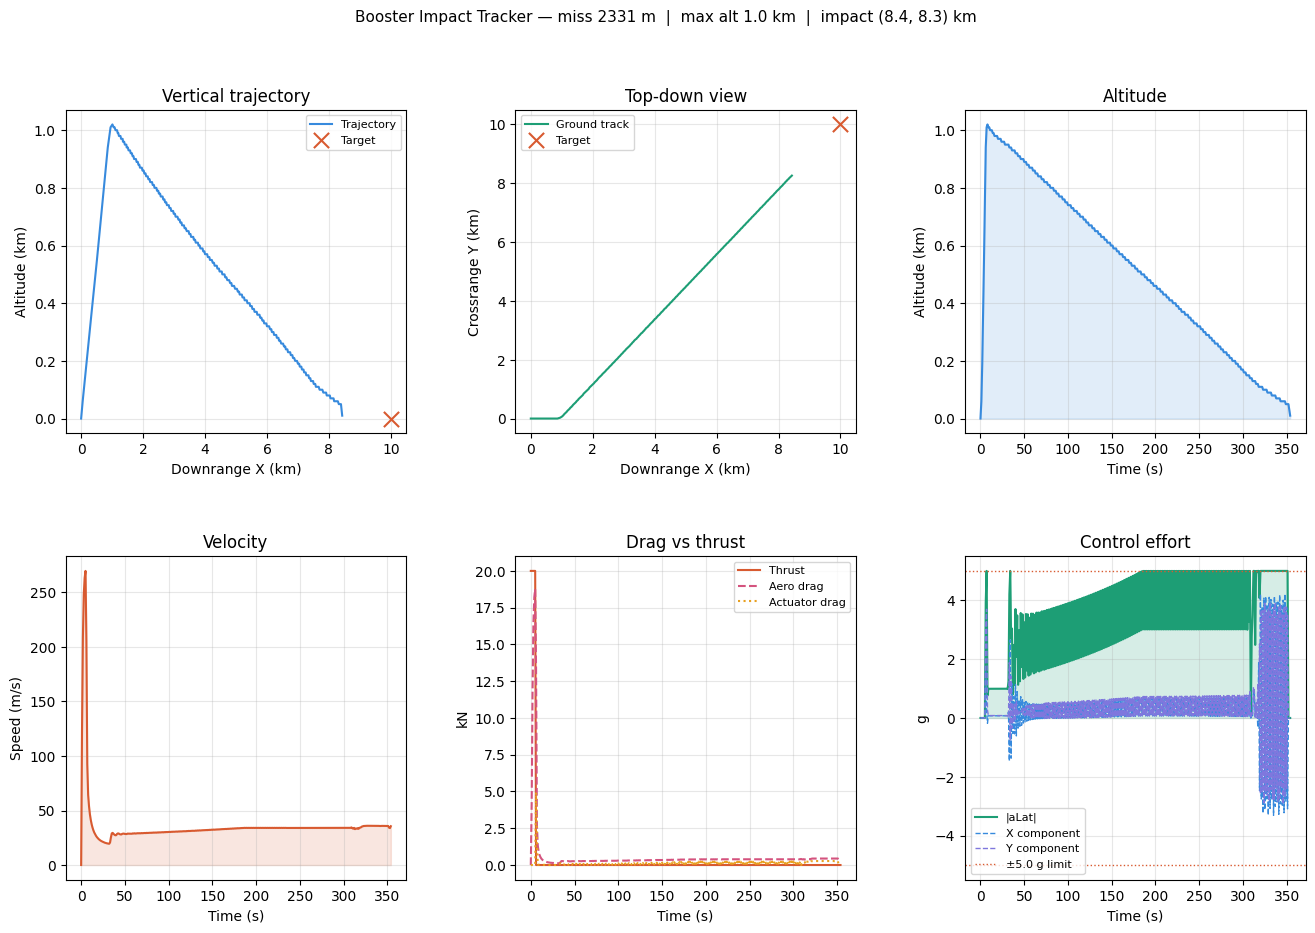

In [4]:
%matplotlib inline
plot_results(result, params)

## Inspect time-series data
All arrays are in `result['series']`. Available keys:

In [5]:
s = result['series']
print('Keys:', list(s.keys()))
print(f"Flight time: {s['t'][-1]} s  ({len(s['t'])} samples)")

Keys: ['t', 'x', 'y', 'h', 'v', 'thr', 'drag_aero', 'drag_ctrl', 'acc', 'aLat', 'aLat_x', 'aLat_y', 'aLat_z']
Flight time: 354.0 s  (355 samples)


## Inspect a specific timestep
Change `i` to look at any point in the flight.

In [6]:
i = 10   # <-- change this
print(f"t={s['t'][i]}s  h={s['h'][i]}km  x={s['x'][i]}km  y={s['y'][i]}km")
print(f"  speed={s['v'][i]}m/s  aLat={s['aLat'][i]}g  (x={s['aLat_x'][i]}g, y={s['aLat_y'][i]}g, z={s['aLat_z'][i]}g)")
print(f"  thrust={s['thr'][i]}kN  drag_aero={s['drag_aero'][i]}kN  drag_ctrl={s['drag_ctrl'][i]}kN")

t=10.0s  h=1.01km  x=1.08km  y=0.15km
  speed=46.6m/s  aLat=0.9928g  (x=0.0737g, y=0.0814g, z=0.9867g)
  thrust=0.0kN  drag_aero=0.68kN  drag_ctrl=0.02kN


## Quick parameter sweep
Run multiple scenarios and compare miss distance.

In [7]:
from dataclasses import replace

angles = [30, 40, 50, 60, 70, 80]
print(f"{'angle':>6}  {'miss_m':>10}  {'impact_x':>10}  {'impact_y':>10}  {'impact_z':>10}  {'max_alt':>10}")
for angle in angles:
    r = simulate(replace(params, launch_angle=angle))
    s = r['summary']
    print(f"{angle:>6}°  {s['miss_distance_m']:>10.0f}  {s['impact_x_km']:>10.2f}  "
          f"{s['impact_y_km']:>10.2f}  {s['impact_z_km']:>10.2f}  {s['max_altitude_km']:>10.2f}")

 angle      miss_m    impact_x    impact_y    impact_z     max_alt
    30°        3916        7.40        7.07       -0.00        0.60
    40°        2730        8.19        7.95       -0.00        0.82
    50°        2331        8.44        8.27       -0.01        1.02
    60°        2096        8.57        8.47       -0.00        1.20
    70°        1784        8.77        8.70       -0.01        1.33
    80°        1628        8.87        8.83       -0.00        1.42


## Run check vectors

In [8]:
!python -m pytest tests/check_vectors.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\Anastasia\AppData\Local\Programs\Python\Python312\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Anastasia\OneDrive\Desktop\Satellite_sim\Code
plugins: anyio-4.13.0
collecting ... collected 13 items

tests/check_vectors.py::TestDeterminism::test_same_params_same_result PASSED [  7%]
tests/check_vectors.py::TestPhysicsInvariants::test_vertical_launch_zero_crossrange PASSED [ 15%]
tests/check_vectors.py::TestPhysicsInvariants::test_zero_propellant_stays_on_ground PASSED [ 23%]
tests/check_vectors.py::TestPhysicsInvariants::test_vacuum_zero_aero_drag PASSED [ 30%]
tests/check_vectors.py::TestPhysicsInvariants::test_altitude_non_negative PASSED [ 38%]
tests/check_vectors.py::TestPhysicsInvariants::test_burnout_altitude_below_max PASSED [ 46%]
tests/check_vectors.py::TestGuidance::test_guidance_reduces_miss PASSED  [ 53%]
tests/check_v